<a href="https://colab.research.google.com/github/Sashanka2001/pre-enhancement--Google-Colab/blob/main/Google_Col_pre_enhancement_facial_recoverability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q mediapipe opencv-python numpy pandas pillow matplotlib scikit-image tqdm datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.9/37.9 MB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 7.0 MB/s eta 0:00:00


In [ ]:
import os

# Define project folder paths
directories = [
    "dataset/original",
    "dataset/cropped",
    "dataset/degraded/blur",
    "dataset/degraded/noise",
    "dataset/degraded/brightness",
    "dataset/degraded/contrast",
    "dataset/degraded/jpeg",
    "dataset/degraded/low_resolution",
    "dataset/metadata",
    "graphs"
]

for folder in directories:
    os.makedirs(folder, exist_ok=True)

print("Cloud workspace folders initialized successfully!")

Cloud workspace folders initialized successfully!


In [ ]:
#1 st 500 images downloading
import os
import shutil
import cv2
from tqdm import tqdm

# Install kagglehub
!pip install -q kagglehub

import kagglehub

# 1. Reset dataset/original directory to remove old LFW images
output_dir = "dataset/original"
if os.path.exists(output_dir):
    shutil.rmtree(output_dir)
os.makedirs(output_dir, exist_ok=True)

# 2. Download FFHQ dataset directly from Kaggle
print("Downloading high-resolution FFHQ dataset from Kaggle...")
kaggle_path = kagglehub.dataset_download("arnaud58/flickrfaceshq-dataset-ffhq")
print(f"Downloaded to Kaggle cache: {kaggle_path}")

# 3. Locate image files inside the Kaggle cache
image_files = []
for root, _, files in os.walk(kaggle_path):
    for file in sorted(files):
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            image_files.append(os.path.join(root, file))

print(f"Total FFHQ images found: {len(image_files)}")

# 4. Convert and save the first 500 high-resolution FFHQ faces
target_count = min(500, len(image_files))
for idx in tqdm(range(target_count), desc="Processing FFHQ faces"):
    src_path = image_files[idx]
    img = cv2.imread(src_path)
    if img is not None:
        dest_path = os.path.join(output_dir, f"face_{idx + 1:04d}.png")
        cv2.imwrite(dest_path, img)

print(f"\nSuccess! 500 high-resolution FFHQ images saved to '{output_dir}/'.")

Using Colab cache for faster access to the 'flickrfaceshq-dataset-ffhq' dataset.
Downloaded to Kaggle cache: /kaggle/input/flickrfaceshq-dataset-ffhq
Total FFHQ images found: 52001


Processing FFHQ faces: 100%|██████████| 500/500 [00:20<00:00, 23.83it/s]


Success! 500 high-resolution FFHQ images saved to 'dataset/original/'.


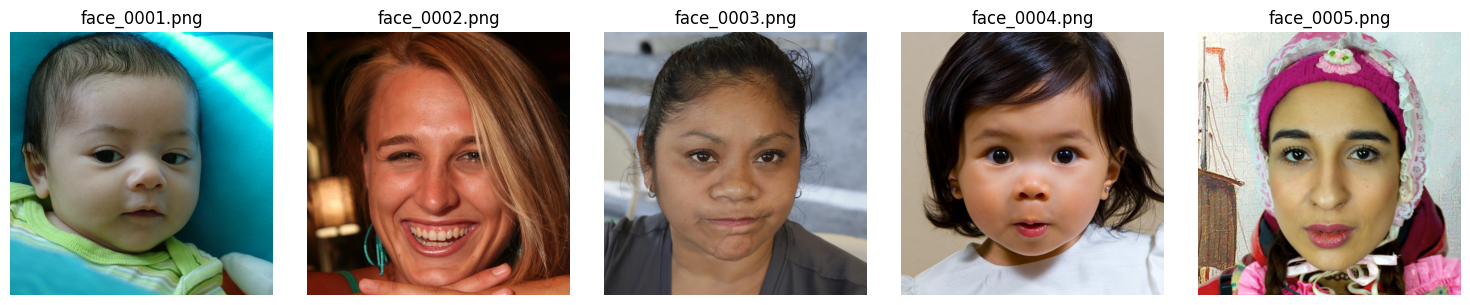

In [ ]:
#Verify New High-Resolution FFHQ Images
import cv2
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 3))
for i in range(5):
    img_path = f"dataset/original/face_{i+1:04d}.png"
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, 5, i + 1)
    plt.imshow(img_rgb)
    plt.title(f"face_{i+1:04d}.png")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
#Verify Image Count & Structural Integrity
import os
import cv2

image_dir = "dataset/original"
files = sorted([f for f in os.listdir(image_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])

valid_count = 0
sample_specs = []

for filename in files:
    path = os.path.join(image_dir, filename)
    img = cv2.imread(path)
    if img is not None:
        valid_count += 1
        if len(sample_specs) < 3:
            sample_specs.append((filename, img.shape))

print(f"Total Valid FFHQ Images Verified: {valid_count}/{len(files)}")
print("\nSample File Specifications:")
for name, shape in sample_specs:
    print(f" - {name}: {shape[1]}x{shape[0]} pixels, {shape[2]} channels (BGR)")

Total Valid FFHQ Images Verified: 500/500

Sample File Specifications:
 - face_0001.png: 512x512 pixels, 3 channels (BGR)
 - face_0002.png: 512x512 pixels, 3 channels (BGR)
 - face_0003.png: 512x512 pixels, 3 channels (BGR)


In [ ]:
# # Step 1: Mount Google Drive & Move Local 500 Images to Drive Storage

# import os
# import shutil
# from google.colab import drive

# # 1. Mount Google Drive
# drive.mount('/content/drive')

# # 2. Define target project paths on Google Drive
# DRIVE_PROJECT = "/content/drive/MyDrive/pre_enhancement_facial_recoverability"
# DIR_ORIGINAL = os.path.join(DRIVE_PROJECT, "dataset/original")
# DIR_CROPPED = os.path.join(DRIVE_PROJECT, "dataset/cropped")
# DIR_DEGRADED = os.path.join(DRIVE_PROJECT, "dataset/degraded")
# DIR_METADATA = os.path.join(DRIVE_PROJECT, "dataset/metadata")

# for path in [DIR_ORIGINAL, DIR_CROPPED, DIR_DEGRADED, DIR_METADATA]:
#     os.makedirs(path, exist_ok=True)

# # 3. Transfer existing local 500 images from Colab to Google Drive
# LOCAL_ORIGINAL = "/content/dataset/original"

# if os.path.exists(LOCAL_ORIGINAL):
#     local_files = [f for f in os.listdir(LOCAL_ORIGINAL) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
#     print(f"Found {len(local_files)} images in local Colab storage.")

#     transferred_count = 0
#     for file in local_files:
#         src = os.path.join(LOCAL_ORIGINAL, file)
#         dst = os.path.join(DIR_ORIGINAL, file)

#         # Copy to Google Drive if not already present
#         if not os.path.exists(dst):
#             shutil.copy(src, dst)
#             transferred_count += 1

#     print(f"Successfully transferred {transferred_count} images to Google Drive!")
#     print(f"Total Original Images now in Google Drive: {len(os.listdir(DIR_ORIGINAL))}")

In [ ]:
# Install rembg with CPU backend support, onnxruntime execution engine, and pillow
!pip install -q "rembg[cpu]" onnxruntime pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.1/23.1 MB 47.2 MB/s eta 0:00:00


In [ ]:
# Step 4: Background Removal & Facial Segmentation (Fixes missing ONNXRuntime backend in Colab)

import os
import shutil
from PIL import Image
from rembg import remove
from tqdm import tqdm

def segment_faces_clean_folder(input_dir: str = "dataset/original",
                               output_dir: str = "dataset/cropped",
                               background_color: tuple = (255, 255, 255),
                               max_images: int = 100):
    """
    Deletes previous cropped images in dataset/cropped/, performs background removal
    on original faces using ONNX runtime, and saves new subject cutouts into dataset/cropped/.

    Parameters:
        input_dir (str): Folder containing raw original images.
        output_dir (str): Folder to store background-removed face images.
        background_color (tuple): RGB color for background (255, 255, 255 = White).
                                  Set to None to preserve transparency.
        max_images (int): Number of images to process (Set to None for all 500 images).
    """
    # 1. Delete previous cropped folder and all old images inside it
    if os.path.exists(output_dir):
        shutil.rmtree(output_dir)
        print(f"Cleared previous images from '{output_dir}/'")

    # 2. Re-create a fresh, empty output directory
    os.makedirs(output_dir, exist_ok=True)

    # 3. Get sorted list of source images
    valid_extensions = ('.png', '.jpg', '.jpeg', '.webp')
    image_files = sorted([f for f in os.listdir(input_dir) if f.lower().endswith(valid_extensions)])

    # Apply batch limit for initial testing
    if max_images is not None:
        image_files = image_files[:max_images]
        print(f"--- Running background removal test on first {len(image_files)} images ---")
    else:
        print(f"--- Running background removal on full dataset ({len(image_files)} images) ---")

    processed_count = 0

    # 4. Process each image with AI segmentation
    for filename in tqdm(image_files, desc="Removing Backgrounds"):
        image_path = os.path.join(input_dir, filename)

        try:
            # Load source image
            input_image = Image.open(image_path)

            # Isolate facial subject and extract background using ONNX model engine
            segmented_image = remove(input_image)

            # Apply clean solid white background
            if background_color is not None:
                canvas = Image.new("RGBA", segmented_image.size, background_color + (255,))
                final_image = Image.alpha_composite(canvas, segmented_image).convert("RGB")
            else:
                final_image = segmented_image

            # Save clean cutout directly to dataset/cropped/
            output_filename = os.path.splitext(filename)[0] + ".png"
            final_image.save(os.path.join(output_dir, output_filename))
            processed_count += 1

        except Exception as e:
            print(f"Error processing {filename}: {e}")

    print(f"\nComplete! '{output_dir}/' now contains only {processed_count} new background-removed images.")

# --- EXECUTION: Test on first 100 images ---
# (Change max_images=100 to max_images=None when ready to process all 500)
segment_faces_clean_folder(input_dir="dataset/original",
                           output_dir="dataset/cropped",
                           background_color=(255, 255, 255),
                           max_images=100)

Cleared previous images from 'dataset/cropped/'
--- Running background removal test on first 100 images ---


Removing Backgrounds:   2%|▏         | 2/100 [03:21<2:43:31, 100.12s/it]

In [ ]:
# # Mount Google Drive to access your 400 GB cloud storage space
# from google.colab import drive
# import os

# drive.mount('/content/drive')

# # Create a dedicated project folder inside your Google Drive
# drive_project_path = '/content/drive/MyDrive/pre_enhancement_facial_recoverability'
# os.makedirs(drive_project_path, exist_ok=True)

# print(f"Google Drive connected! Saving files to: {drive_project_path}")

Mounted at /content/drive
Google Drive connected! Saving files to: /content/drive/MyDrive/pre_enhancement_facial_recoverability


In [ ]:
# Base path pointing directly to your 400 GB Google Drive storage
# DRIVE_BASE = "/content/drive/MyDrive/pre_enhancement_facial_recoverability"

# # Updated directories inside Google Drive
# DIR_ORIGINAL = f"{DRIVE_BASE}/dataset/original"
# DIR_CROPPED = f"{DRIVE_BASE}/dataset/cropped"
# DIR_DEGRADED = f"{DRIVE_BASE}/dataset/degraded"
# DIR_METADATA = f"{DRIVE_BASE}/dataset/metadata"

# for folder in [DIR_ORIGINAL, DIR_CROPPED, DIR_DEGRADED, DIR_METADATA]:
#     os.makedirs(folder, exist_ok=True)

In [ ]:
# # Step 2: Background Removal & Facial Segmentation (Directly to Google Drive)

# !pip install -q "rembg[cpu]" onnxruntime pillow

# import os
# from PIL import Image
# from rembg import remove
# from tqdm import tqdm

# # Define target project paths on Google Drive (re-defined for cell scope)
# DRIVE_PROJECT = "/content/drive/MyDrive/pre_enhancement_facial_recoverability"
# DIR_ORIGINAL = os.path.join(DRIVE_PROJECT, "dataset/original")
# DIR_CROPPED = os.path.join(DRIVE_PROJECT, "dataset/cropped")

# def segment_faces_directly_to_drive(input_dir: str,
#                                     output_dir: str,
#                                     background_color: tuple = (255, 255, 255),
#                                     max_images: int = 10):
#     """
#     Reads original faces from Google Drive, performs AI portrait background removal,
#     and writes background-removed cutouts directly into Google Drive.
#     """
#     os.makedirs(output_dir, exist_ok=True)

#     valid_extensions = ('.png', '.jpg', '.jpeg', '.webp')
#     image_files = sorted([f for f in os.listdir(input_dir) if f.lower().endswith(valid_extensions)])

#     if max_images is not None:
#         image_files = image_files[:max_images]
#         print(f"--- Running background removal test on {len(image_files)} images ---")
#     else:
#         print(f"--- Running background removal on all {len(image_files)} images ---")

#     processed_count = 0

#     for filename in tqdm(image_files, desc="Removing Backgrounds"):
#         src_path = os.path.join(input_dir, filename)
#         output_filename = os.path.splitext(filename)[0] + ".png"
#         dest_path = os.path.join(output_dir, output_filename)

#         try:
#             input_image = Image.open(src_path)
#             segmented_image = remove(input_image)

#             # Apply clean white background canvas
#             if background_color is not None:
#                 canvas = Image.new("RGBA", segmented_image.size, background_color + (255,))
#                 final_image = Image.alpha_composite(canvas, segmented_image).convert("RGB")
#             else:
#                 final_image = segmented_image

#             # Save cutout straight to Google Drive
#             final_image.save(dest_path)
#             processed_count += 1

#         except Exception as e:
#             print(f"Error processing {filename}: {e}")

#     print(f"\nComplete! {processed_count} background-removed cutouts saved directly to Google Drive.")

# # --- EXECUTION: Test on first 100 images ---
# # (Change max_images=100 to max_images=None when ready to run all 500 images)
# segment_faces_directly_to_drive(input_dir=DIR_ORIGINAL,
#                                 output_dir=DIR_CROPPED, #"/content/dataset/cropped, <-- Cplab store", DIR_CROPPED <-- Drive path
#                                 background_color=(255, 255, 255),
#                                 max_images=10)